In [1]:
from utils import *

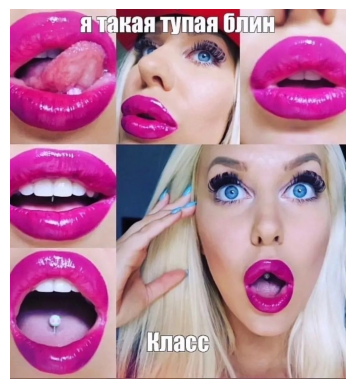

In [2]:
image = cv2.imread("./klass.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')
plt.show()

In [3]:
image_float = image.astype(np.float64)

R = image_float[:, :, 0]
G = image_float[:, :, 1]
B = image_float[:, :, 2]

In [4]:
svd_res = {}
iter_nums = [10, 50, 100]
r_vals = [5, 10, 20, 50]

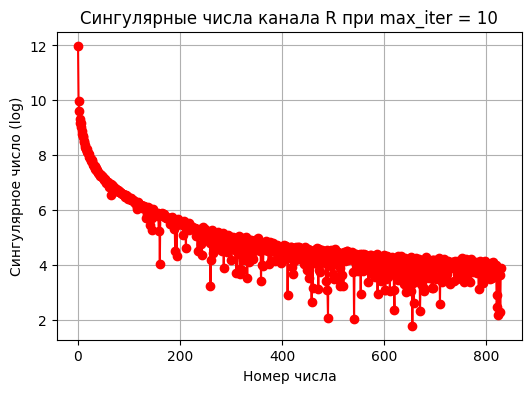

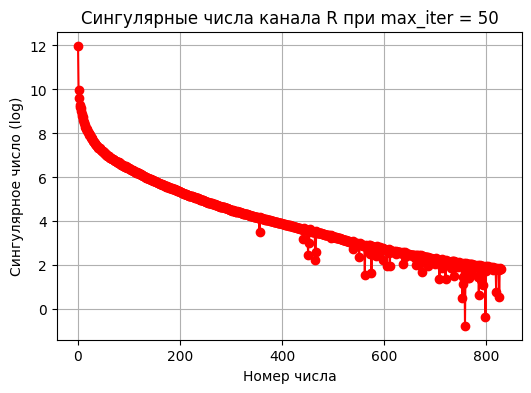

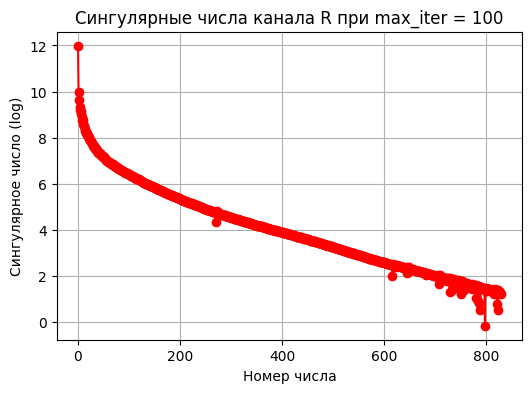

In [5]:
svd_res['R'] = {}
for n in iter_nums:
    U, S, Vt = svd_via_power_method(R, max_iter=n, enable_below_zero_sigma_warning=False)
    recon = trunc_recon(U, S, Vt, r=U.shape[1])
    err_full = np.linalg.norm(R - recon, ord='fro')
    svd_res['R'][n] = (U, S, Vt, err_full)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='red')
    ax.set_xlabel('Номер числа')
    ax.set_ylabel('Сингулярное число (log)')

    ax.set_title(f'Сингулярные числа канала R при max_iter = {n}')
    ax.grid()
    plt.show()

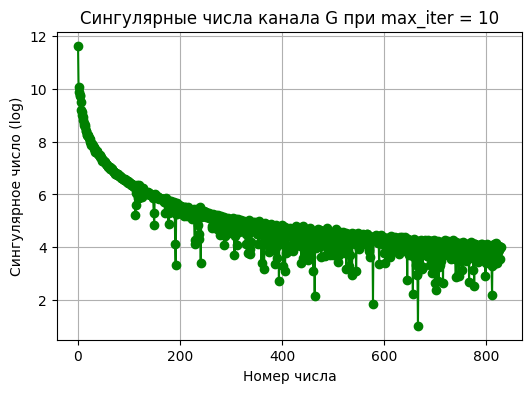

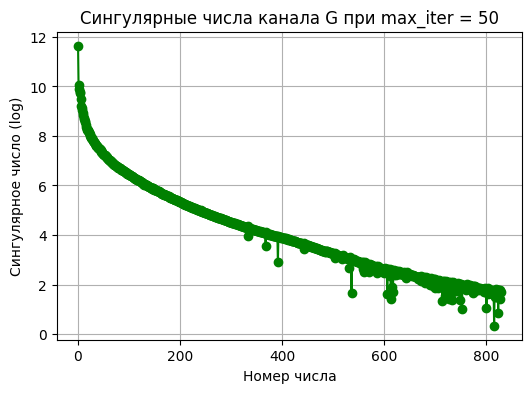

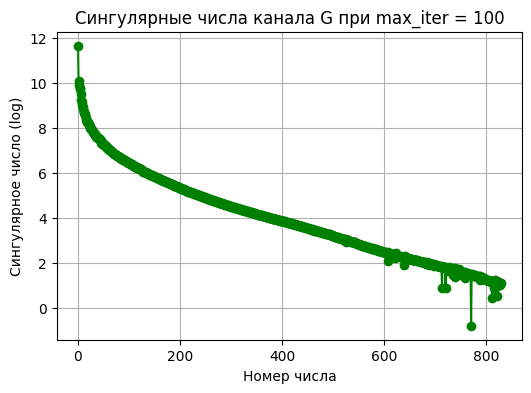

In [6]:
svd_res['G'] = {}
for n in iter_nums:
    U, S, Vt = svd_via_power_method(G, max_iter=n, enable_below_zero_sigma_warning=False)
    recon = trunc_recon(U, S, Vt, r=U.shape[1])
    err_full = np.linalg.norm(G - recon, ord='fro')
    svd_res['G'][n] = (U, S, Vt, err_full)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='green')
    ax.set_xlabel('Номер числа')
    ax.set_ylabel('Сингулярное число (log)')

    ax.set_title(f'Сингулярные числа канала G при max_iter = {n}')
    ax.grid()
    plt.show()

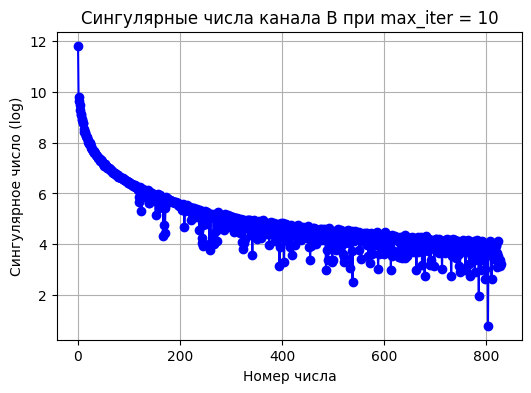

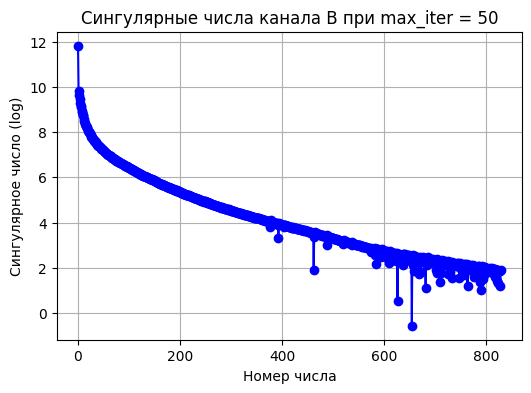

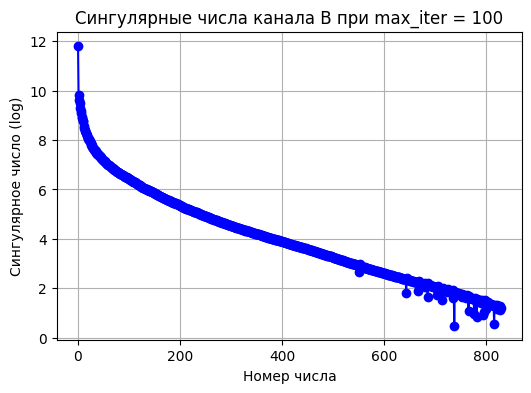

In [7]:
svd_res['B'] = {}
for n in iter_nums:
    U, S, Vt = svd_via_power_method(B, max_iter=n, enable_below_zero_sigma_warning=False)
    recon = trunc_recon(U, S, Vt, r=U.shape[1])
    err_full = np.linalg.norm(B - recon, ord='fro')
    svd_res['B'][n] = (U, S, Vt, err_full)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(1, len(S) + 1), np.log(S), marker='o', color='blue')
    ax.set_xlabel('Номер числа')
    ax.set_ylabel('Сингулярное число (log)')

    ax.set_title(f'Сингулярные числа канала B при max_iter = {n}')
    ax.grid()
    plt.show()

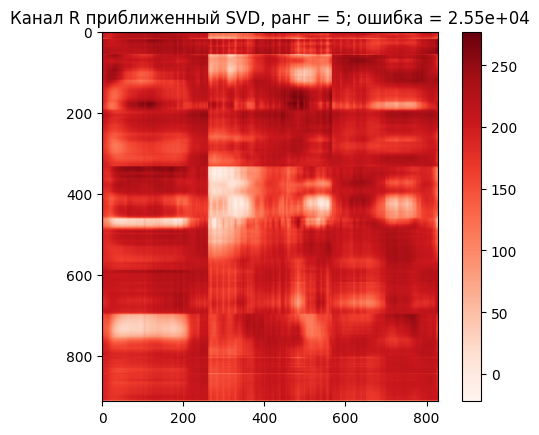

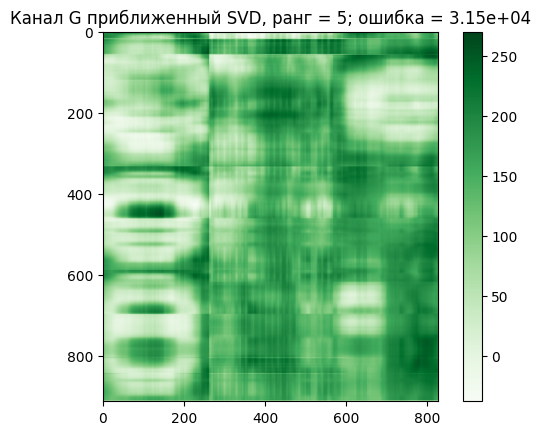

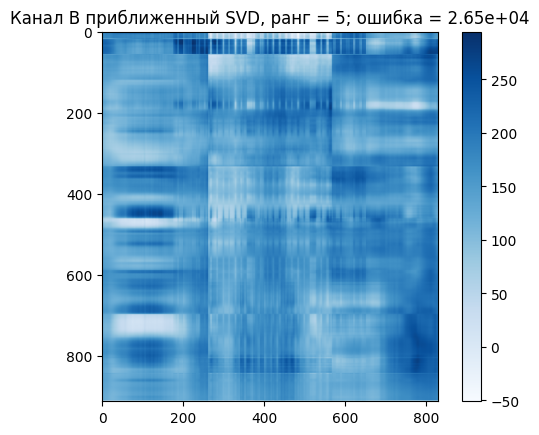

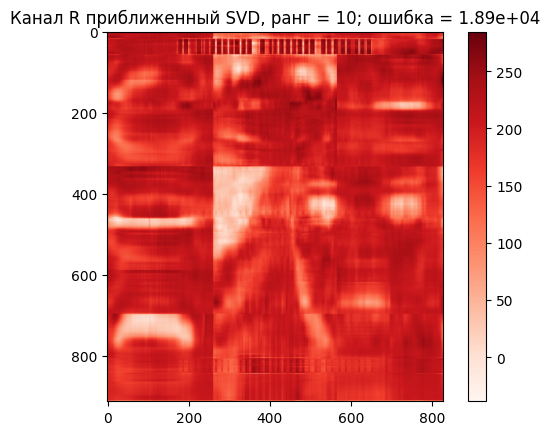

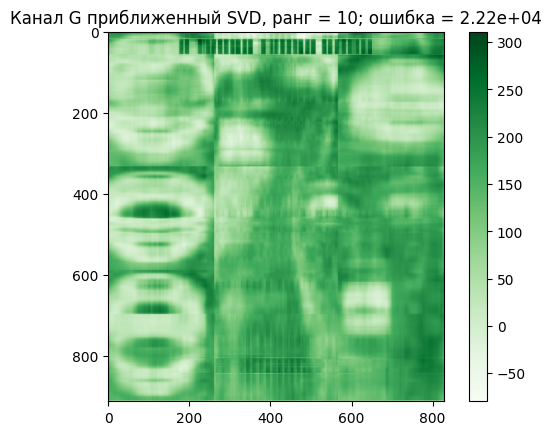

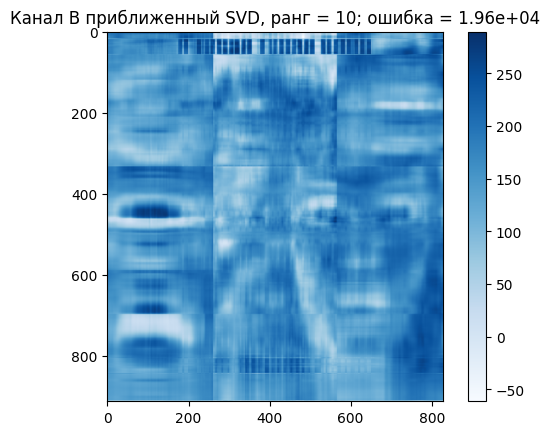

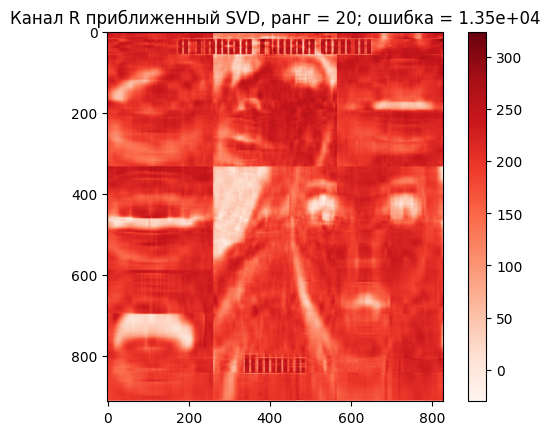

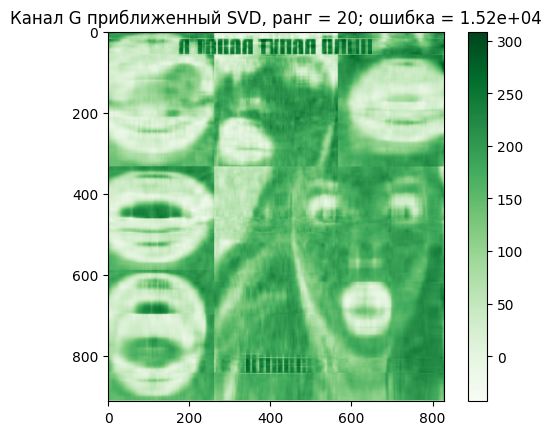

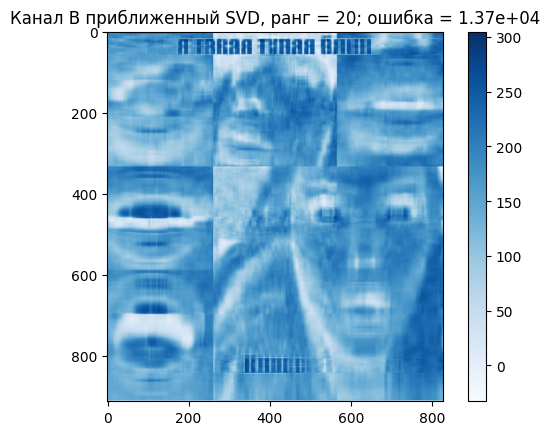

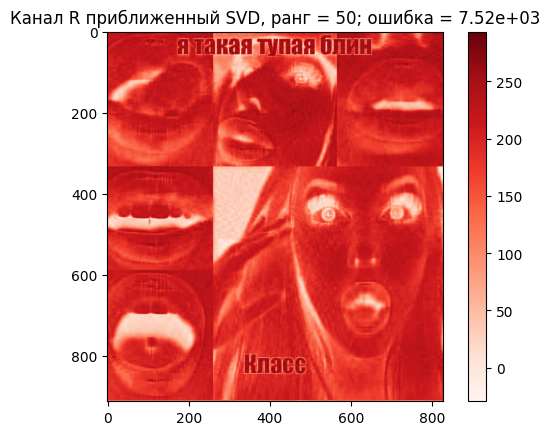

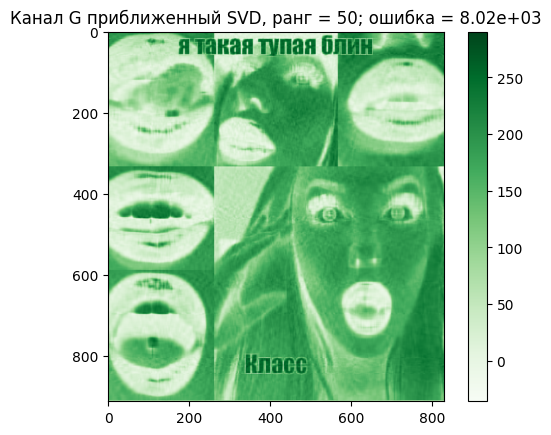

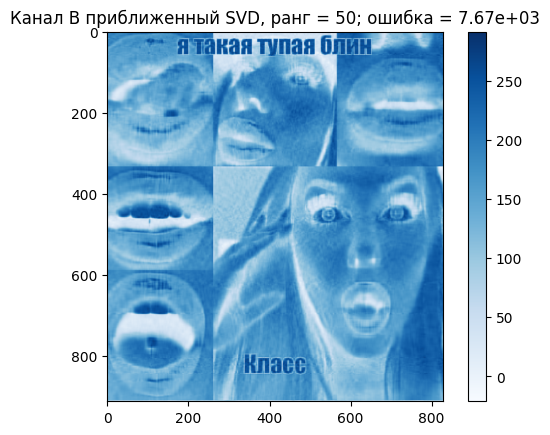

In [8]:
UR, SR, VtR = svd_via_power_method(R, enable_below_zero_sigma_warning=False)
err_fullR = np.linalg.norm(trunc_recon(UR, SR, VtR, r=UR.shape[1]) - R, ord='fro')

UG, SG, VtG = svd_via_power_method(G, enable_below_zero_sigma_warning=False)
err_fullG = np.linalg.norm(trunc_recon(UG, SG, VtG, r=UG.shape[1]) - G, ord='fro')

UB, SB, VtB = svd_via_power_method(B, enable_below_zero_sigma_warning=False)
err_fullB = np.linalg.norm(trunc_recon(UB, SB, VtB, r=UB.shape[1]) - B, ord='fro')

for r in r_vals:
    recon_r = trunc_recon(UR, SR, VtR, r)
    err = np.linalg.norm(recon_r - R, ord='fro')

    plt.figure()
    plt.imshow(recon_r, cmap='Reds')
    plt.title(f"Канал R приближенный SVD, ранг = {r}; ошибка = {err:.2e}")
    plt.colorbar()
    plt.show()

    recon_r = trunc_recon(UG, SG, VtG, r)
    err = np.linalg.norm(recon_r - G, ord='fro')

    plt.figure()
    plt.imshow(recon_r, cmap='Greens')
    plt.title(f"Канал G приближенный SVD, ранг = {r}; ошибка = {err:.2e}")
    plt.colorbar()
    plt.show()


    recon_r = trunc_recon(UB, SB, VtB, r)
    err = np.linalg.norm(recon_r - B, ord='fro')

    plt.figure()
    plt.imshow(recon_r, cmap='Blues')
    plt.title(f"Канал B приближенный SVD, ранг = {r}; ошибка = {err:.2e}")
    plt.colorbar()
    plt.show()


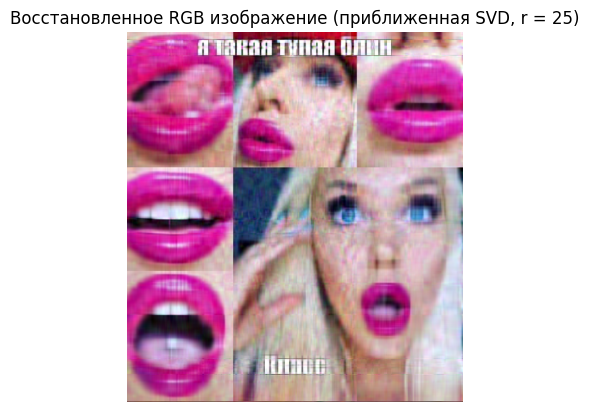

In [9]:
r_fin = 25

recon_R_fin = trunc_recon(UR, SR, VtR, r_fin)
recon_G_fin = trunc_recon(UG, SG, VtG, r_fin)
recon_B_fin = trunc_recon(UB, SB, VtB, r_fin)

recon_im = np.dstack((recon_R_fin, recon_G_fin, recon_B_fin))
recon_im = np.clip(recon_im, 0, 255).astype(np.uint8)

plt.figure()
plt.imshow(recon_im)
plt.title(f"Восстановленное RGB изображение (приближенная SVD, r = {r_fin})")
plt.axis("off")
plt.show()

Собственные значения (метод Якоби): [ 6.55611640e+01  4.44226956e+00 -3.43359001e-03]
Собственные значения (numpy): [ 6.55611640e+01  4.44226956e+00 -3.43359001e-03]


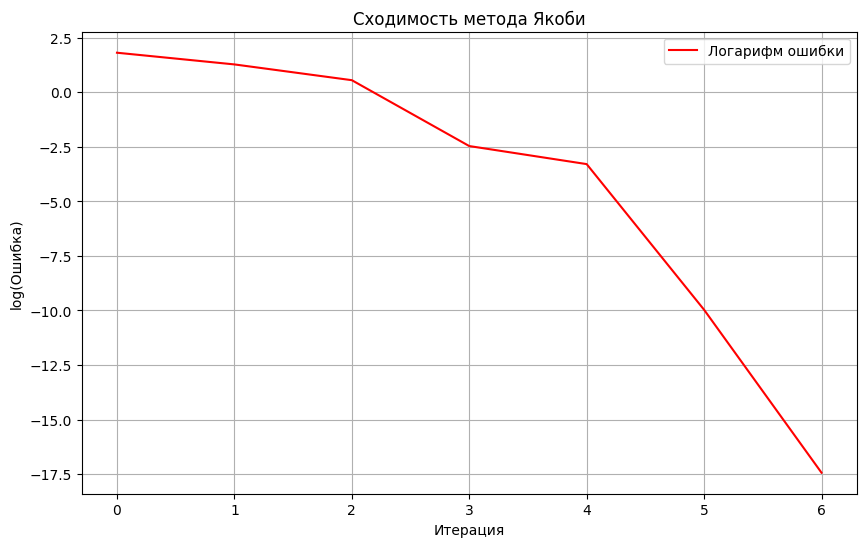

In [10]:
rrr = np.array([[1, 2, 3],
                [2, 4, 5],
                [3, 5, 65]])

jacobi_eigenvalues, l, error_history = jacobi_eigenvalue(rrr)
numpy_eigenvalues = np.sort(np.linalg.eigvals(rrr))[::-1]

print('Собственные значения (метод Якоби):', jacobi_eigenvalues)
print('Собственные значения (numpy):', numpy_eigenvalues)

# Визуализация сходимости
plt.figure(figsize=(10, 6))
plt.plot(
    np.arange(len(error_history)), 
    np.log(error_history), 
    color='red', 
    label='Логарифм ошибки'
)
plt.xlabel('Итерация')
plt.ylabel('log(Ошибка)')
plt.title('Сходимость метода Якоби')
plt.legend()
plt.grid(True)
plt.show()